<a href="https://colab.research.google.com/github/monikaly13/waste-sorting-assistant/blob/main/train_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch torchvision accelerate -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
files.upload()   # choose kaggle.json

!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mostafaabla/garbage-classification
!unzip -q garbage-classification.zip -d /content/garbage12

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:06<00:00, 36.7MB/s]



In [4]:
import shutil, os
src = "/content/garbage12/garbage_classification"
dst = "/content/waste_merged"
rename = {"brown-glass": "glass", "green-glass": "glass", "white-glass": "glass"}

for c in os.listdir(src):
    out = f"{dst}/{rename.get(c, c)}"
    os.makedirs(out, exist_ok=True)
    for f in os.listdir(f"{src}/{c}"):
        shutil.copy(f"{src}/{c}/{f}", f"{out}/{c}_{f}")

print(sorted(os.listdir(dst)))

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
print(os.listdir("/content/trashnet_data/dataset-resized"))

['glass', 'cardboard', 'plastic', 'metal', 'paper', 'trash', '.DS_Store']


In [5]:
from datasets import load_dataset

dataset = load_dataset("imagefolder", data_dir="/content/waste_merged")
print(dataset)

Resolving data files:   0%|          | 0/15515 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 15515
    })
})


In [6]:
print(dataset["train"].features)
print(dataset["train"][0])

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash'])}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=280x180 at 0x7834A5B24050>, 'label': 0}


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/waste-sorting-assistant/hf_cache'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from collections import Counter

labels = dataset["train"]["label"]
label_names = dataset["train"].features["label"].names
counts = Counter(labels)

for i, name in enumerate(label_names):
    print(f"{name}: {counts[i]} images")

battery: 945 images
biological: 985 images
cardboard: 891 images
clothes: 5325 images
glass: 2011 images
metal: 769 images
paper: 1050 images
plastic: 865 images
shoes: 1977 images
trash: 697 images


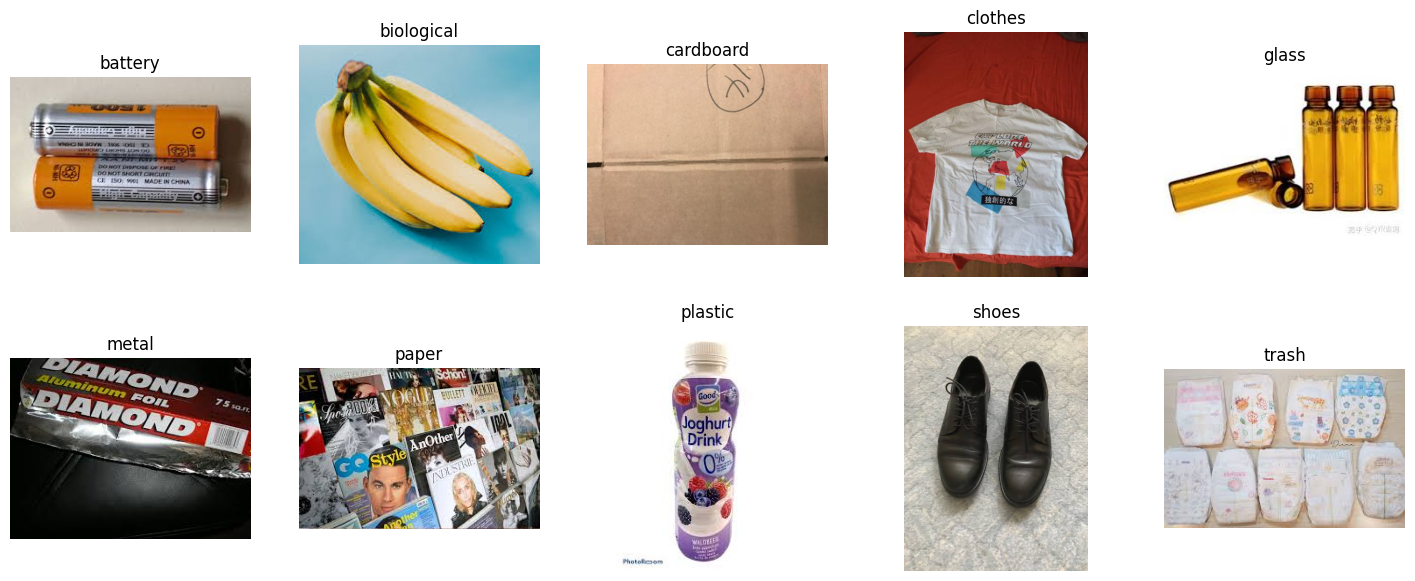

In [10]:
import matplotlib.pyplot as plt
import math

n = len(label_names)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 3.5 * rows))
axes = axes.flatten()
for i, name in enumerate(label_names):
    idx = labels.index(i)
    img = dataset["train"][idx]["image"]
    axes[i].imshow(img)
    axes[i].set_title(name)
    axes[i].axis("off")
for j in range(n, len(axes)):      # hide unused empty boxes
    axes[j].axis("off")
plt.show()

In [11]:
# Split off 30% for val+test, stratified by label
split1 = dataset["train"].train_test_split(test_size=0.3, seed=42, stratify_by_column="label")

# Split that 30% in half -> 15% val, 15% test
split2 = split1["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

from datasets import DatasetDict
dataset = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

print(dataset)

# Confirm class balance held up in each split
from collections import Counter
for split_name in ["train", "validation", "test"]:
    print(f"\n{split_name}:")
    split_labels = dataset[split_name]["label"]
    counts = Counter(split_labels)
    for i, name in enumerate(label_names):
        print(f"  {name}: {counts[i]}")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 10860
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2327
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2328
    })
})

train:
  battery: 661
  biological: 689
  cardboard: 624
  clothes: 3727
  glass: 1408
  metal: 538
  paper: 735
  plastic: 606
  shoes: 1384
  trash: 488

validation:
  battery: 142
  biological: 148
  cardboard: 133
  clothes: 799
  glass: 301
  metal: 116
  paper: 157
  plastic: 130
  shoes: 296
  trash: 105

test:
  battery: 142
  biological: 148
  cardboard: 134
  clothes: 799
  glass: 302
  metal: 115
  paper: 158
  plastic: 129
  shoes: 297
  trash: 104


In [12]:
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True  # needed since we're replacing the final layer
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [13]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset = dataset.with_transform(preprocess)

In [14]:
sample = dataset["train"][0]
print(sample["pixel_values"].shape)
print(sample["labels"])

torch.Size([3, 224, 224])
6


In [16]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00


In [17]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [18]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-waste-sorter",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    remove_unused_columns=False,
)

In [19]:
split1 = dataset["train"].train_test_split(test_size=0.3, seed=42, stratify_by_column="label")
split2 = split1["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label")

from datasets import DatasetDict
dataset = DatasetDict({
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

In [20]:
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [21]:
def preprocess(examples):
    images = [img.convert("RGB") for img in examples["image"]]
    inputs = processor(images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

dataset = dataset.with_transform(preprocess)

In [22]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [23]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-waste-sorter",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20,
    remove_unused_columns=False,
)

In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.079516,0.082777,0.978514
2,0.022139,0.086947,0.977901
3,0.014087,0.089009,0.978514
4,0.024688,0.095760,0.978514
5,0.020826,0.100513,0.978514
6,0.000241,0.101590,0.980356
7,0.000197,0.104653,0.979742
8,0.000180,0.105133,0.979742


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=3808, training_loss=0.03927434701191265, metrics={'train_runtime': 2634.8619, 'train_samples_per_second': 23.081, 'train_steps_per_second': 1.445, 'total_flos': 4.713090751705448e+18, 'train_loss': 0.03927434701191265, 'epoch': 8.0})

In [25]:
import os

save_path = "/content/drive/MyDrive/waste-sorting-assistant/vit-waste-model-final"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
processor.save_pretrained(save_path)

print("Saved to:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/waste-sorting-assistant/vit-waste-model-final


In [26]:
test_results = trainer.evaluate(dataset["test"])
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy
0.000180,0.066332,8,0.986495


{'eval_loss': 0.06633224338293076, 'eval_accuracy': 0.9864947820748926}


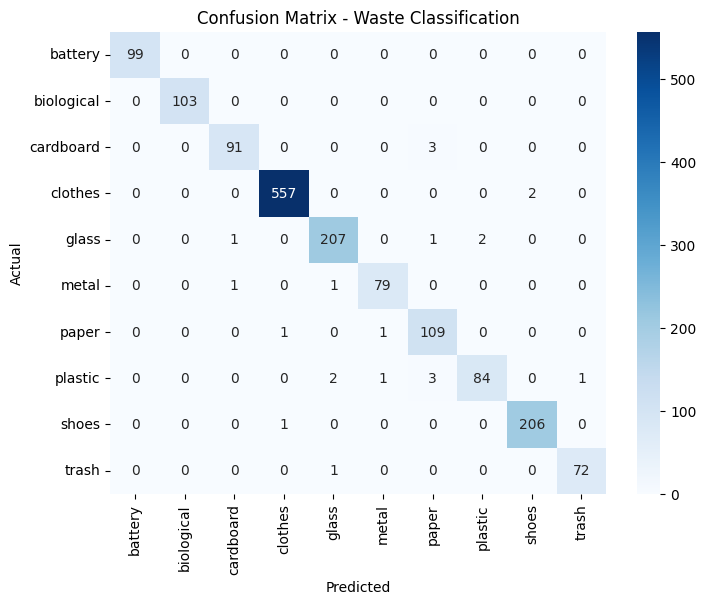

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on the test set
predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Build confusion matrix
cm = confusion_matrix(true_labels, preds)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Waste Classification")
plt.show()

In [28]:
print(len(dataset["test"]))
print(len(true_labels))

1629
1629


In [29]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7602
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1629
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1629
    })
})


In [ ]:
print(os.listdir("/content/trashnet_data/dataset-resized"))

from datasets import load_dataset
raw = load_dataset("imagefolder", data_dir="/content/trashnet_data/dataset-resized")
print(raw)

['glass', 'cardboard', 'plastic', 'metal', 'paper', 'trash', '.DS_Store']


Resolving data files:   0%|          | 0/2527 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2527
    })
})


In [41]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

bin_map = {
    "cardboard": ("Recyclable", "Flatten it, keep it dry, put it in recycling."),
    "glass":     ("Recyclable", "Rinse and put in glass recycling. Broken glass: wrap and use general waste."),
    "metal":     ("Recyclable", "Rinse cans and put in recycling. Batteries and electronics do NOT go here."),
    "paper":     ("Recyclable", "Keep clean and dry. Greasy paper goes in compost or general waste."),
    "plastic":   ("Recyclable", "Empty, rinse, and recycle. Soft film plastic may need store drop-off."),
    "biological":("Organic / Compostable", "Put in a compost or food-waste bin."),
    "battery":   ("Hazardous", "Never put in trash or recycling. Take to a battery or hazardous-waste drop-off."),
    "clothes":   ("General / Landfill", "Donate if wearable; otherwise textile recycling or general waste."),
    "shoes":     ("General / Landfill", "Donate if wearable; otherwise general waste."),
    "trash":     ("General / Landfill", "Not recyclable. Put in the general waste bin."),
}

device = next(model.parameters()).device  # find out where the model lives

def predict_waste(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}  # move inputs to same device as model

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(-1).item()
    predicted_label = label_names[predicted_class_id]
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_class_id].item()

    # Get the disposal instruction or fallback to a default message
    instruction = bin_map.get(predicted_label, "Unknown — Please check local guidelines")

    print(f"Predicted: {predicted_label} ({confidence:.1%} confidence)")
    print(f"Instruction: {instruction}")

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{predicted_label} — {instruction}")
    plt.show()

Predicted: plastic (99.9% confidence)
Instruction: ('Recyclable', 'Empty, rinse, and recycle. Soft film plastic may need store drop-off.')


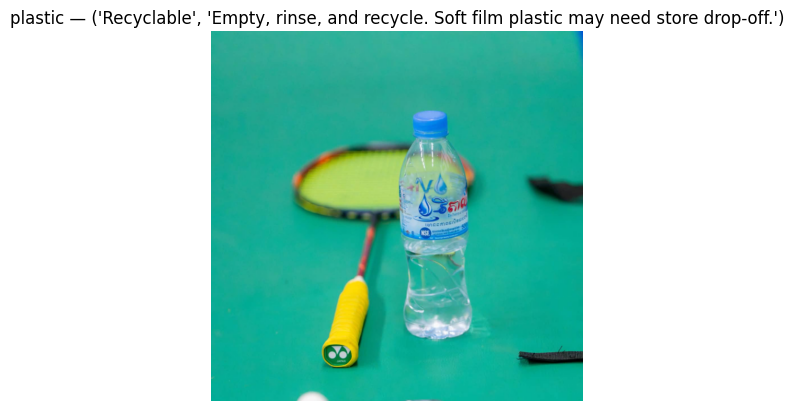

In [42]:
predict_waste("/content/vital.png")

Predicted: plastic (48.2% confidence)
Instruction: ('Recyclable', 'Empty, rinse, and recycle. Soft film plastic may need store drop-off.')


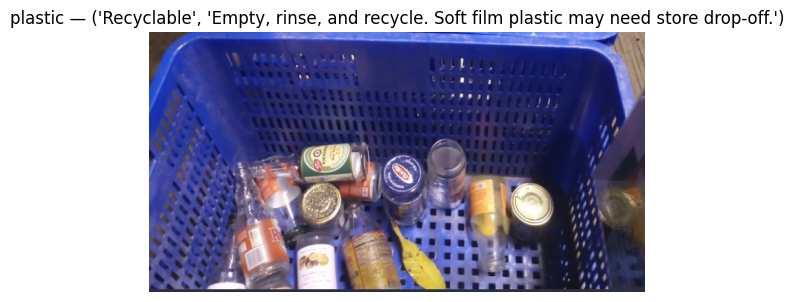

In [43]:
predict_waste("/content/metal.png")

Predicted: metal (96.1% confidence)
Instruction: ('Recyclable', 'Rinse cans and put in recycling. Batteries and electronics do NOT go here.')


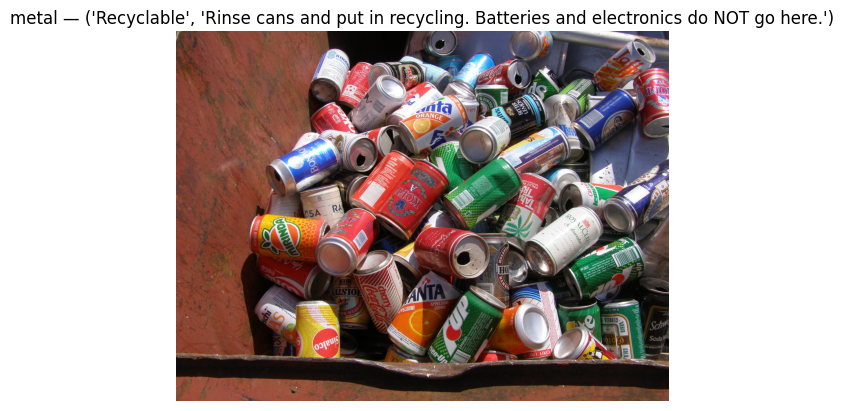

In [44]:
predict_waste("/content/metal#2.jpg")

Predicted: biological (99.8% confidence)
Instruction: ('Organic / Compostable', 'Put in a compost or food-waste bin.')


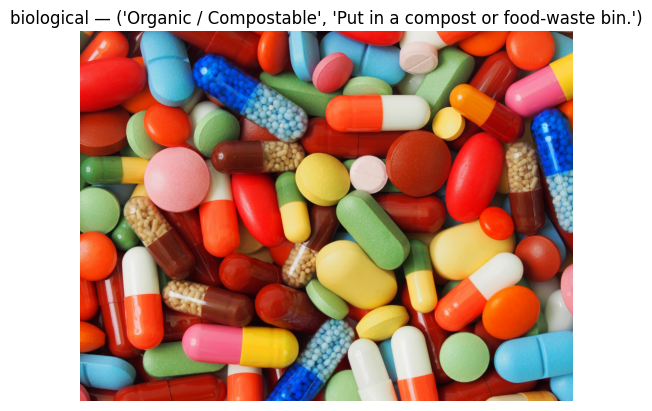

In [45]:
predict_waste("/content/med.jpg")

Predicted: clothes (99.5% confidence)
Instruction: ('General / Landfill', 'Donate if wearable; otherwise textile recycling or general waste.')


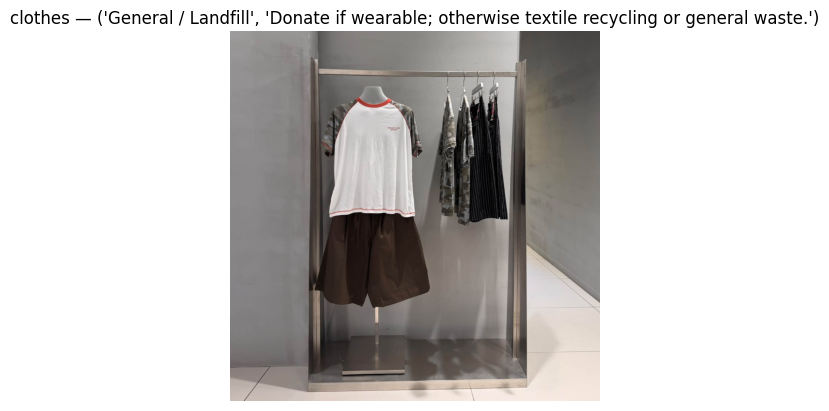

In [49]:
predict_waste("/content/clothes.jpg")

Predicted: clothes (38.1% confidence)
Instruction: ('General / Landfill', 'Donate if wearable; otherwise textile recycling or general waste.')


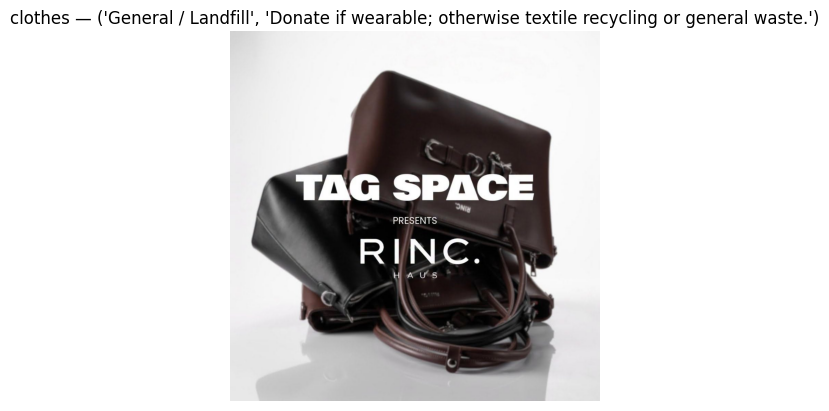

In [50]:
predict_waste("/content/bag.jpg")

Predicted: clothes (99.3% confidence)
Instruction: ('General / Landfill', 'Donate if wearable; otherwise textile recycling or general waste.')


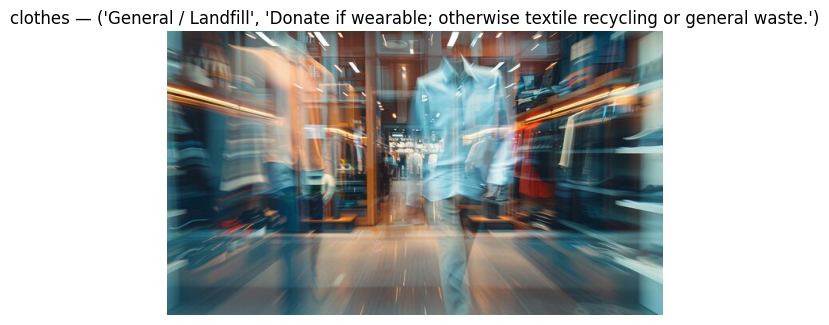

In [52]:
predict_waste("/content/blur_clothes.jpg")

Predicted: clothes (68.6% confidence)
Instruction: ('Donation', 'Textile Recycling Bin')


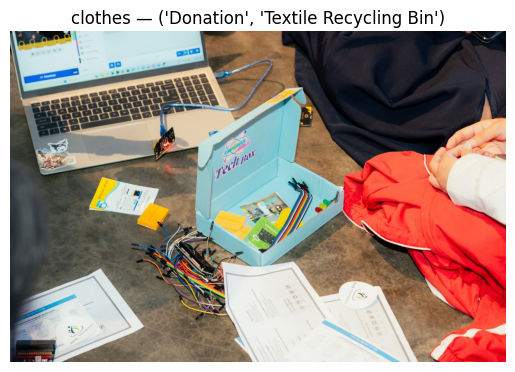

In [54]:
predict_waste("/content/box.jpg")

Predicted: paper (98.8% confidence)
Instruction: ('Recyclable', 'Blue Bin')


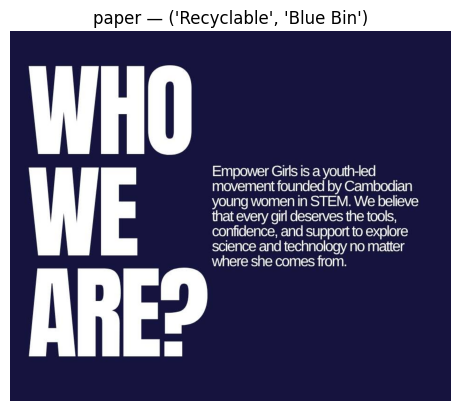

In [55]:
predict_waste("/content/text.jpg")

Predicted: battery (100.0% confidence)
Instruction: ('Hazardous', 'Special E-Waste Disposal')


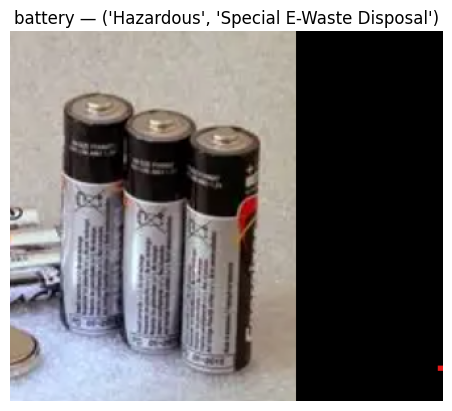

In [56]:
predict_waste("/content/battery.png")

Predicted: biological (99.7% confidence)
Instruction: ('Organic', 'Green Bin (Compost)')


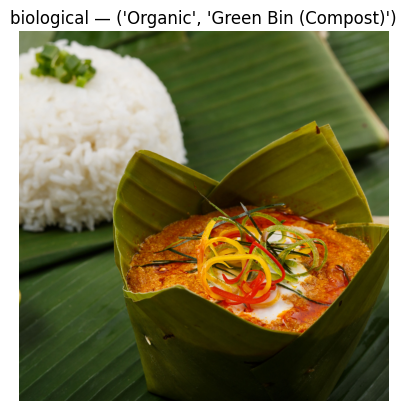

In [57]:
predict_waste("/content/food.jpg")

In [46]:
print(model.config.id2label)

{0: 'battery', 1: 'biological', 2: 'cardboard', 3: 'clothes', 4: 'glass', 5: 'metal', 6: 'paper', 7: 'plastic', 8: 'shoes', 9: 'trash'}


In [ ]:
!pip install gradio -q

In [53]:
import gradio as gr
from PIL import Image
import torch

# Updated bin_map with all 10 categories formatted for Gradio
bin_map = {
    "battery": ("Hazardous", "Special E-Waste Disposal"),
    "biological": ("Organic", "Green Bin (Compost)"),
    "cardboard": ("Recyclable", "Blue Bin"),
    "clothes": ("Donation", "Textile Recycling Bin"),
    "glass": ("Recyclable", "Blue Bin"),
    "metal": ("Recyclable", "Blue Bin"),
    "paper": ("Recyclable", "Blue Bin"),
    "plastic": ("Recyclable", "Blue Bin"),
    "shoes": ("Donation", "Textile Recycling Bin"),
    "trash": ("Non-Recyclable", "General Waste Bin")
}

device = next(model.parameters()).device

def classify_waste(image):
    if image is None:
        return "Please upload or take a photo", ""

    image = image.convert("RGB")
    inputs = processor(image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_id = outputs.logits.argmax(-1).item()
    predicted_label = label_names[predicted_class_id]
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_class_id].item()

    recyclable, bin_name = bin_map.get(predicted_label, ("Unknown", "Please check local guidelines"))

    result = f"{predicted_label.upper()}"
    detail = f"{recyclable} — {bin_name}\nConfidence: {confidence:.0%}"

    return result, detail

with gr.Blocks() as app:
    gr.Markdown("# ♻️ Waste Sorter")
    gr.Markdown("Take a photo or upload one — I'll tell you where it goes!")

    with gr.Row():
        image_input = gr.Image(type="pil", label="Scan Waste", sources=["upload", "webcam"])

    classify_btn = gr.Button("Identify", variant="primary", size="lg")

    with gr.Row():
        result_output = gr.Textbox(label="Item", interactive=False, text_align="center")
    with gr.Row():
        detail_output = gr.Textbox(label="Instruction", interactive=False, text_align="center")

    classify_btn.click(
        fn=classify_waste,
        inputs=image_input,
        outputs=[result_output, detail_output]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8a7ff8049d3a15b63.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
